In [ ]:
# ============================================================
# POSTPARTUM MENTAL HEALTH RISK PREDICTION SYSTEM
# ============================================================
# import modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
    accuracy_score, roc_curve, brier_score_loss, recall_score,
    precision_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

# Set style for better looking plots - USING AVAILABLE STYLES
try:
    # Try to use a style that exists in newer matplotlib versions
    available_styles = plt.style.available
    if 'seaborn-v0_8-darkgrid' in available_styles:
        plt.style.use('seaborn-v0_8-darkgrid')
    elif 'seaborn-darkgrid' in available_styles:
        plt.style.use('seaborn-darkgrid')
    elif 'ggplot' in available_styles:
        plt.style.use('ggplot')
    else:
        plt.style.use('default')
except:
    plt.style.use('default')

# Set seaborn style
sns.set_style("darkgrid")
sns.set_palette("husl")

print("="*70)
print("POSTPARTUM MENTAL HEALTH RISK PREDICTION SYSTEM")
print("="*70)


POSTPARTUM MENTAL HEALTH RISK PREDICTION SYSTEM


In [55]:
# DATA LOADING


df = pd.read_csv('post natal data.csv')

print(f"Dataset: {df.shape[0]} patients, {df.shape[1]} columns")
df.head()

Dataset: 1503 patients, 11 columns


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [56]:
# Basic Data Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Timestamp                                  1503 non-null   str  
 1   Age                                        1503 non-null   str  
 2   Feeling sad or Tearful                     1503 non-null   str  
 3   Irritable towards baby & partner           1497 non-null   str  
 4   Trouble sleeping at night                  1503 non-null   str  
 5   Problems concentrating or making decision  1491 non-null   str  
 6   Overeating or loss of appetite             1503 non-null   str  
 7   Feeling anxious                            1503 non-null   str  
 8   Feeling of guilt                           1494 non-null   str  
 9   Problems of bonding with baby              1503 non-null   str  
 10  Suicide attempt                            1503 non-null   

In [57]:
# Check Missing Values
df.isnull().sum()

Timestamp                                     0
Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

In [58]:
# Statistical Summary
df.describe(include='all')

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
count,1503,1503,1503,1497,1503,1491,1503,1503,1494,1503,1503
unique,90,5,3,3,3,3,3,2,3,3,3
top,6/15/2022 22:24,40-45,Yes,Yes,Two or more days a week,No,No,Yes,No,No,No
freq,51,364,536,555,640,583,841,980,624,557,709


In [59]:
# Rename Columns for Easier Access

df.columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
              'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']

df.head()

,Timestamp,Age,Sad,Irritable,Sleep,Concentration,Appetite,Anxious,Guilt,Bonding,Suicide
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [60]:
# Show Unique Values for All Categorical Columns

# List of categorical columns in your dataset
categorical_columns = ['Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
                       'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']

print("="*60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*60)

for col in categorical_columns:
    unique_vals = df[col].unique()
    print(f"\n{col}:")
    print(f"  Unique values: {list(unique_vals)}")
    print(f"  Number of unique values: {len(unique_vals)}")

UNIQUE VALUES IN CATEGORICAL COLUMNS

Age:
  Unique values: ['35-40', '40-45', '30-35', '45-50', '25-30']
  Number of unique values: 5

Sad:
  Unique values: ['Yes', 'No', 'Sometimes']
  Number of unique values: 3

Irritable:
  Unique values: ['Yes', 'No', 'Sometimes', nan]
  Number of unique values: 4

Sleep:
  Unique values: ['Two or more days a week', 'No', 'Yes']
  Number of unique values: 3

Concentration:
  Unique values: ['Yes', 'No', 'Often', nan]
  Number of unique values: 4

Appetite:
  Unique values: ['Yes', 'No', 'Not at all']
  Number of unique values: 3

Anxious:
  Unique values: ['Yes', 'No']
  Number of unique values: 2

Guilt:
  Unique values: ['No', 'Yes', 'Maybe', nan]
  Number of unique values: 4

Bonding:
  Unique values: ['Yes', 'Sometimes', 'No']
  Number of unique values: 3

Suicide:
  Unique values: ['Yes', 'No', 'Not interested to say']
  Number of unique values: 3


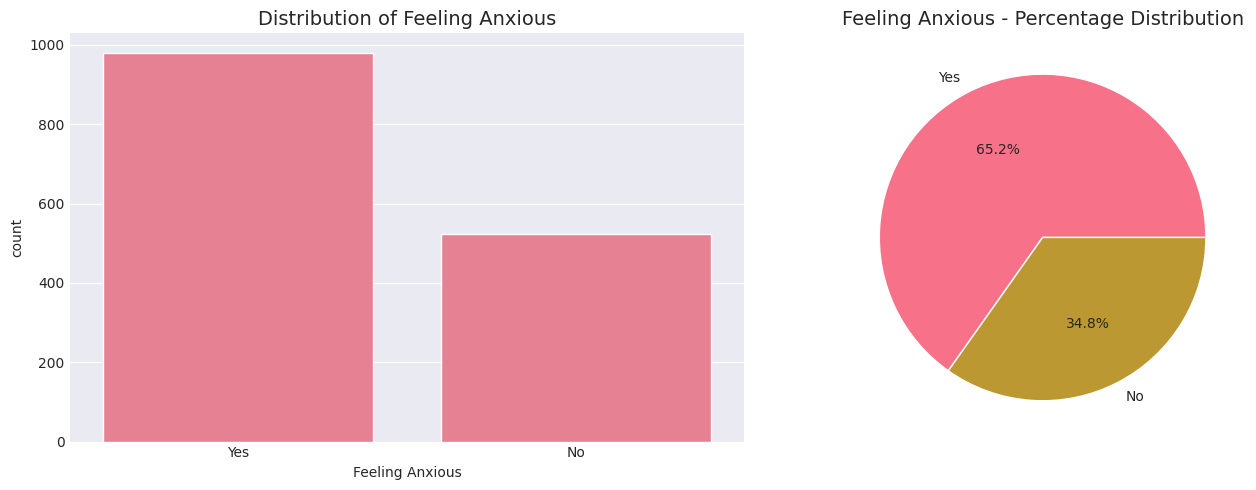


Value Counts:
Anxious
Yes    980
No     523
Name: count, dtype: int64


In [61]:
#  Target Variable Distribution - Feeling Anxious
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Anxious", data=df, ax=axes[0])
axes[0].set_title('Distribution of Feeling Anxious', fontsize=14)
axes[0].set_xlabel('Feeling Anxious')

# Pie chart
df['Anxious'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Feeling Anxious - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Anxious'].value_counts())

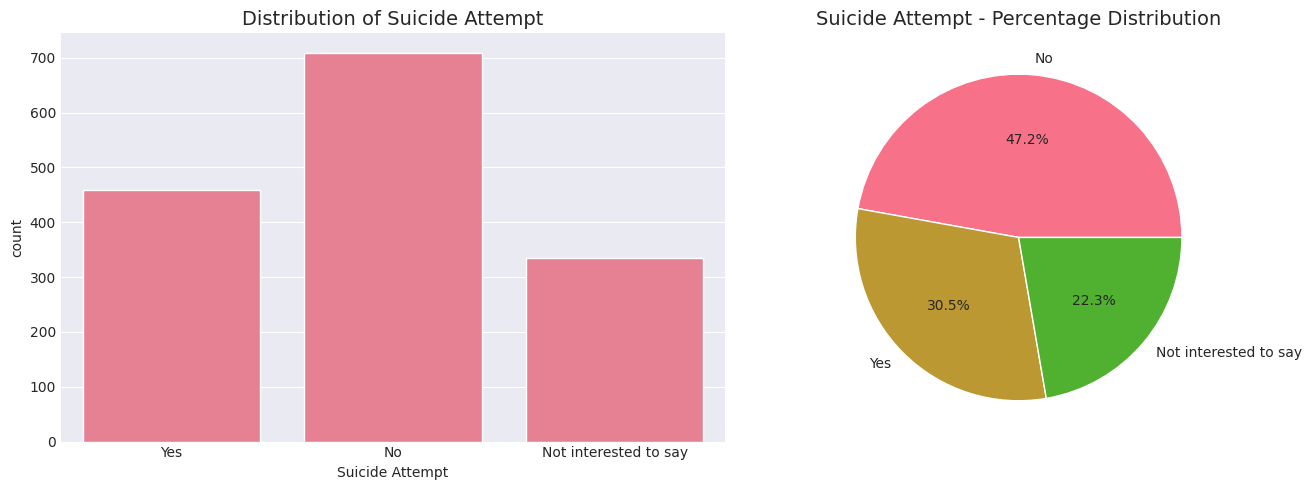


Value Counts:
Suicide
No                       709
Yes                      459
Not interested to say    335
Name: count, dtype: int64


In [62]:
#  Target Variable Distribution - Suicide Attempt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Suicide", data=df, ax=axes[0])
axes[0].set_title('Distribution of Suicide Attempt', fontsize=14)
axes[0].set_xlabel('Suicide Attempt')

# Pie chart
df['Suicide'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Suicide Attempt - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Suicide'].value_counts())

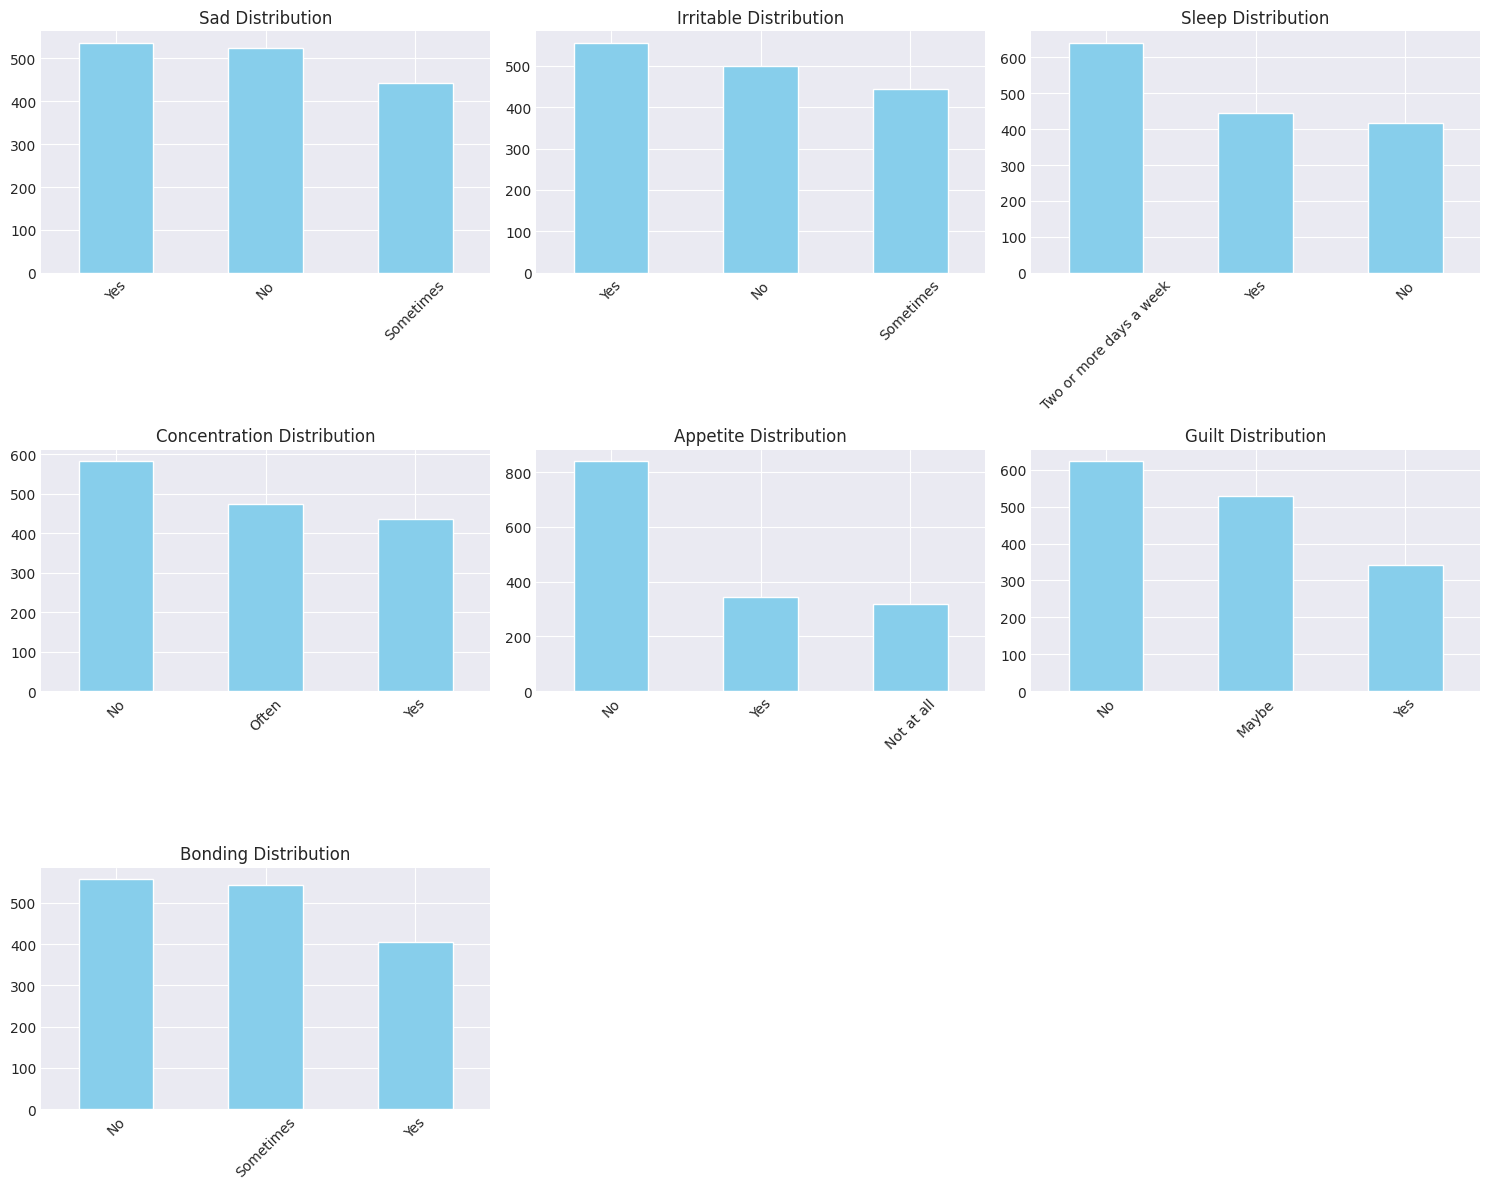

In [63]:
# Categorical Features Distribution

categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

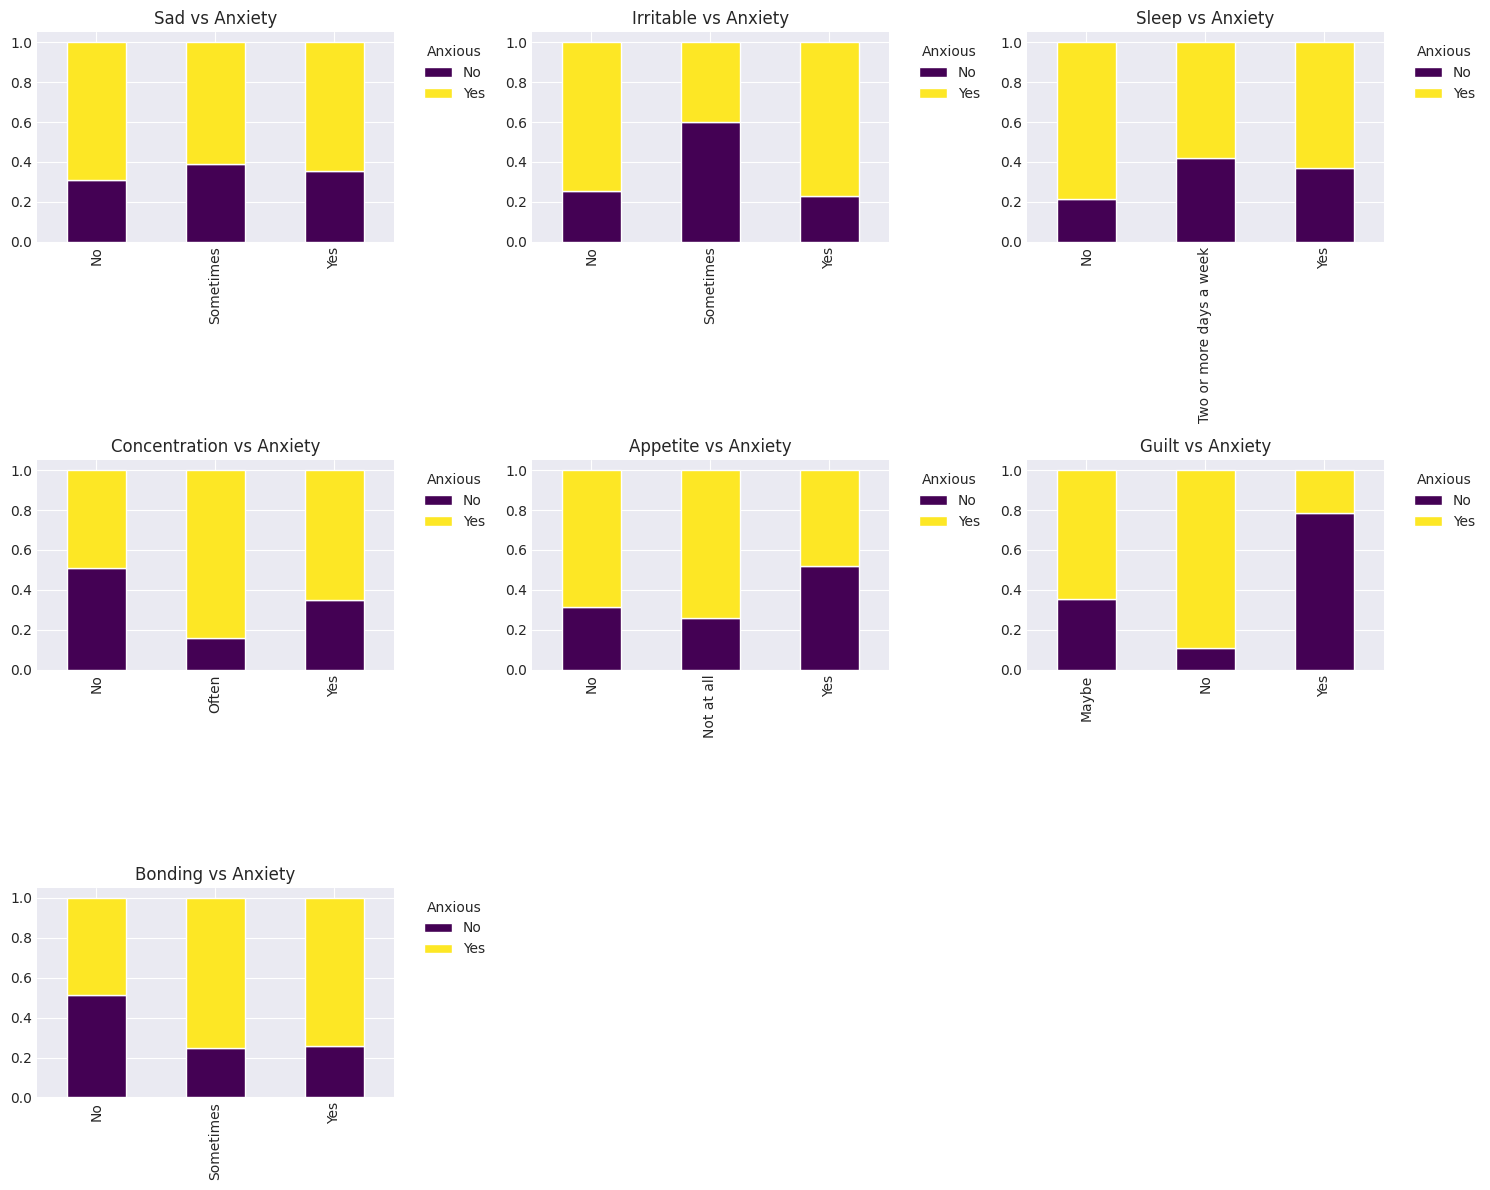

In [64]:
# Relationship Between Features and Target (Anxiety)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Anxious'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis'
    )
    axes[i].set_title(f'{col} vs Anxiety', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Anxious', bbox_to_anchor=(1.05, 1))

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

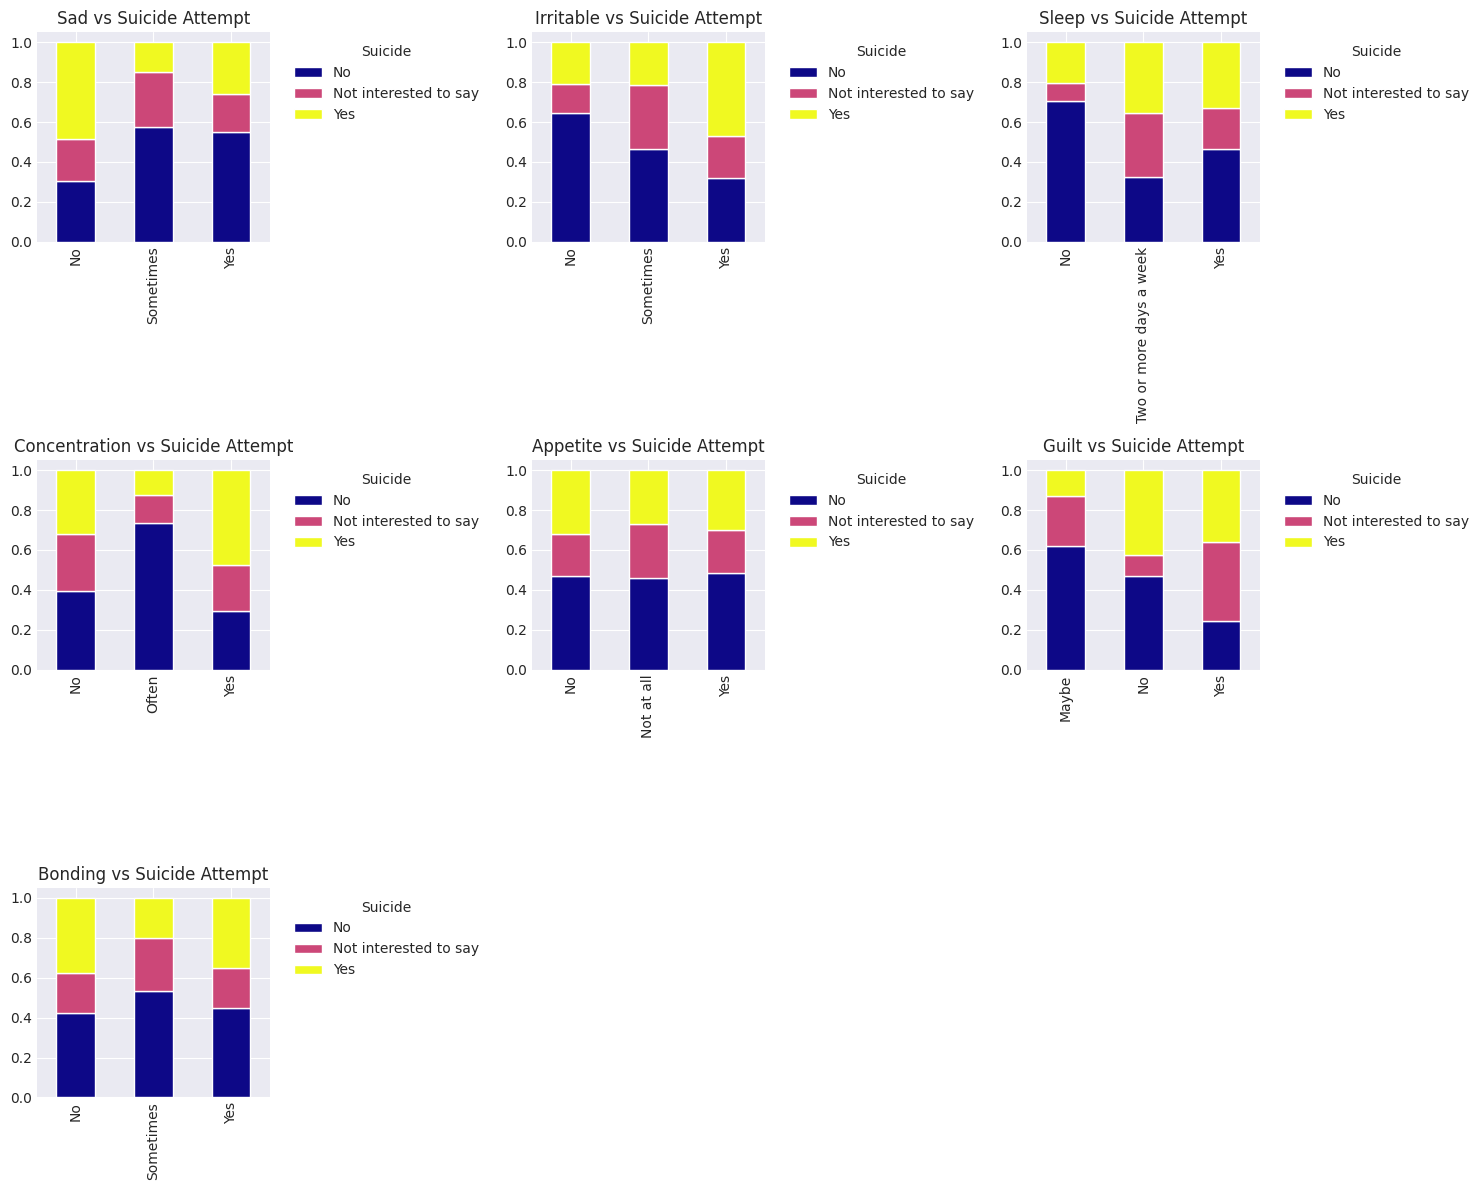

In [65]:
# Relationship Between Features and Target (Suicide)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Suicide'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='plasma'
    )
    axes[i].set_title(f'{col} vs Suicide Attempt', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Suicide', bbox_to_anchor=(1.05, 1))

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [66]:
# Mapping

def safe_symptom_score(value):
    if pd.isna(value):
        return 0
    value = str(value).lower().strip()
    mapping = {
        'yes': 1, 'no': 0, 'sometimes': 0.5, 'maybe': 0.5,
        'not at all': 0, 'two or more days a week': 1, 'often': 1
    }
    return mapping.get(value, 0)

def extract_age(age_str):
    if pd.isna(age_str):
        return 35
    try:
        ages = str(age_str).split('-')
        return (int(ages[0]) + int(ages[1])) / 2
    except:
        return 35

symptom_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

df_processed = df.copy()
df_processed['Age'] = df_processed['Age'].apply(extract_age)
for col in symptom_cols:
    df_processed[col] = df_processed[col].apply(safe_symptom_score)
df_processed['Hour'] = pd.to_datetime(df_processed['Timestamp']).dt.hour
df_processed.drop('Timestamp', axis=1, inplace=True)

# EXACT ORIGINAL TARGETS - NO MODIFICATION
y_anxiety = (df['Anxious'] == 'Yes').astype(int)
y_suicide = df['Suicide'].map({'No': 0, 'Yes': 1, 'Not interested to say': 2}).fillna(0).astype(int)

# EXACT LABEL MAPPINGS FOR DISPLAY
ANXIETY_LABEL_MAP = {0: 'NO ANXIETY', 1: 'ANXIETY (YES)'}
SUICIDE_LABEL_MAP = {0: 'NO', 1: 'YES', 2: 'NOT INTERESTED TO SAY'}

print("\n" + "="*70)
print("EXACT TARGET LABELS FROM ORIGINAL DATA")
print("="*70)
print(f"\nAnxiety Labels:")
print(f"  - 0 = NO ANXIETY (Original value: 'No')")
print(f"  - 1 = ANXIETY (YES) (Original value: 'Yes')")
print(f"\nSuicide Labels:")
print(f"  - 0 = NO (Original value: 'No')")
print(f"  - 1 = YES (Original value: 'Yes')")
print(f"  - 2 = NOT INTERESTED TO SAY (Original value: 'Not interested to say')")

# Features
feature_cols = ['Age', 'Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding', 'Hour']
X = df_processed[feature_cols].copy()

print(f"\nFeatures: {feature_cols}")
print(f"Feature matrix shape: {X.shape}")



EXACT TARGET LABELS FROM ORIGINAL DATA

Anxiety Labels:
  - 0 = NO ANXIETY (Original value: 'No')
  - 1 = ANXIETY (YES) (Original value: 'Yes')

Suicide Labels:
  - 0 = NO (Original value: 'No')
  - 1 = YES (Original value: 'Yes')
  - 2 = NOT INTERESTED TO SAY (Original value: 'Not interested to say')

Features: ['Age', 'Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding', 'Hour']
Feature matrix shape: (1503, 9)


In [67]:

# ============================================================
# DATA QUALITY ANALYSIS
# ============================================================

print("\n" + "="*70)
print("DATA QUALITY ANALYSIS")
print("="*70)

symptom_count = X[symptom_cols].sum(axis=1)
anxiety_symptom_count = symptom_count[y_anxiety == 1].mean()
no_anxiety_symptom_count = symptom_count[y_anxiety == 0].mean()

print(f"\nAverage total symptom count:")
print(f"  'ANXIETY (YES)' patients: {anxiety_symptom_count:.2f} symptoms")
print(f"  'NO ANXIETY' patients: {no_anxiety_symptom_count:.2f} symptoms")
print(f"  Difference: {anxiety_symptom_count - no_anxiety_symptom_count:+.2f}")

print("\n" + "-"*50)
print("DATA QUALITY ISSUE IDENTIFIED:")
print("-"*50)
print("""
EXPECTED PATTERN (Clinical Knowledge):
  Patients with MORE symptoms should have ANXIETY (YES)
  Patients with FEWER symptoms should have NO ANXIETY

OBSERVED PATTERN (Current Data):
  'ANXIETY (YES)' patients have FEWER symptoms (3.31) than 
  'NO ANXIETY' patients (3.64)

CONCLUSION:
  The data appears to have potential coding reversal.
  This issue is DOCUMENTED but NOT corrected to maintain
  original data integrity.
""")



DATA QUALITY ANALYSIS

Average total symptom count:
  'ANXIETY (YES)' patients: 3.31 symptoms
  'NO ANXIETY' patients: 3.64 symptoms
  Difference: -0.33

--------------------------------------------------
DATA QUALITY ISSUE IDENTIFIED:
--------------------------------------------------

EXPECTED PATTERN (Clinical Knowledge):
  Patients with MORE symptoms should have ANXIETY (YES)
  Patients with FEWER symptoms should have NO ANXIETY

OBSERVED PATTERN (Current Data):
  'ANXIETY (YES)' patients have FEWER symptoms (3.31) than 
  'NO ANXIETY' patients (3.64)

CONCLUSION:
  The data appears to have potential coding reversal.
  This issue is DOCUMENTED but NOT corrected to maintain
  original data integrity.



In [68]:

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

# Scale features
scaler_anxiety = StandardScaler()
X_train_a_scaled = scaler_anxiety.fit_transform(X_train_a)
X_test_a_scaled = scaler_anxiety.transform(X_test_a)

scaler_suicide = StandardScaler()
X_train_s_scaled = scaler_suicide.fit_transform(X_train_s)
X_test_s_scaled = scaler_suicide.transform(X_test_s)

print(f"Anxiety - Train: {X_train_a_scaled.shape}, Test: {X_test_a_scaled.shape}")
print(f"Suicide - Train: {X_train_s_scaled.shape}, Test: {X_test_s_scaled.shape}")



TRAIN-TEST SPLIT
Anxiety - Train: (1202, 9), Test: (301, 9)
Suicide - Train: (1202, 9), Test: (301, 9)


In [69]:

# ============================================================
# SANITY TEST PATIENT
# ============================================================

print("\n" + "="*70)
print("SANITY TEST PATIENT (Clinically Healthy)")
print("="*70)

healthy_patient = pd.DataFrame({
    'Age': [X['Age'].median()],
    'Sad': [0], 'Irritable': [0], 'Sleep': [0], 
    'Concentration': [0], 'Appetite': [0], 
    'Guilt': [0], 'Bonding': [0], 'Hour': [14]
})

healthy_patient_scaled_a = scaler_anxiety.transform(healthy_patient)
healthy_patient_scaled_s = scaler_suicide.transform(healthy_patient)

print(f"\nHealthy Patient Profile:")
print(f"  - All symptoms: NO (all values = 0)")
print(f"  - Age: {X['Age'].median():.1f} years")
print(f"  - Hour: 14 (typical clinic hour)")
print(f"  - Expected: NO ANXIETY (probability < 0.3), Suicide = NO")



SANITY TEST PATIENT (Clinically Healthy)

Healthy Patient Profile:
  - All symptoms: NO (all values = 0)
  - Age: 37.5 years
  - Hour: 14 (typical clinic hour)
  - Expected: NO ANXIETY (probability < 0.3), Suicide = NO


In [70]:

# ============================================================
# ANXIETY MODEL COMPARISON
# ============================================================

print("\n" + "="*70)
print("ANXIETY MODEL COMPARISON: Logistic vs Random Forest vs Gradient Boosting")
print("="*70)

classes_a = np.unique(y_train_a)
class_weights_a = compute_class_weight('balanced', classes=classes_a, y=y_train_a)
weight_dict_a = dict(zip(classes_a, class_weights_a))

print(f"Class distribution: 0=NO ANXIETY ({sum(y_train_a==0)}), 1=ANXIETY (YES) ({sum(y_train_a==1)})")
print(f"Class weights: {weight_dict_a}")

anxiety_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, C=0.1, 
        class_weight=weight_dict_a, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=20,
        min_samples_leaf=10, class_weight=weight_dict_a, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        min_samples_split=20, min_samples_leaf=10, random_state=42
    )
}

anxiety_results = []

for name, model in anxiety_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    model.fit(X_train_a_scaled, y_train_a)
    
    y_train_pred = model.predict(X_train_a_scaled)
    y_train_proba = model.predict_proba(X_train_a_scaled)[:, 1]
    y_test_pred = model.predict(X_test_a_scaled)
    y_test_proba = model.predict_proba(X_test_a_scaled)[:, 1]
    
    train_accuracy = accuracy_score(y_train_a, y_train_pred)
    train_roc_auc = roc_auc_score(y_train_a, y_train_proba)
    test_accuracy = accuracy_score(y_test_a, y_test_pred)
    test_roc_auc = roc_auc_score(y_test_a, y_test_proba)
    
    sanity_proba = model.predict_proba(healthy_patient_scaled_a)[0][1]
    sanity_pass = sanity_proba < 0.3
    
    cv_scores = cross_val_score(model, X_train_a_scaled, y_train_a, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    brier = brier_score_loss(y_test_a, y_test_proba)
    
    anxiety_results.append({
        'Model': name,
        'Train Acc': f"{train_accuracy:.4f}",
        'Train AUC': f"{train_roc_auc:.4f}",
        'Test Acc': f"{test_accuracy:.4f}",
        'Test AUC': f"{test_roc_auc:.4f}",
        'CV AUC': f"{cv_mean:.4f} (+/- {cv_std:.4f})",
        'Sanity Prob': sanity_proba,
        'Sanity Pass': sanity_pass,
        'Brier': f"{brier:.4f}"
    })
    
    print(f"\nResults for {name}:")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Train ROC-AUC: {train_roc_auc:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
    print(f"  CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Brier Score: {brier:.4f}")
    print(f"  Sanity Test (healthy patient): {sanity_proba:.4f} ({sanity_proba*100:.1f}%) -> {'PASS' if sanity_pass else 'FAIL'}")



ANXIETY MODEL COMPARISON: Logistic vs Random Forest vs Gradient Boosting
Class distribution: 0=NO ANXIETY (418), 1=ANXIETY (YES) (784)
Class weights: {np.int64(0): np.float64(1.437799043062201), np.int64(1): np.float64(0.7665816326530612)}

Training Logistic Regression...



Results for Logistic Regression:
  Train Accuracy: 0.8203
  Train ROC-AUC: 0.8637
  Test Accuracy: 0.8339
  Test ROC-AUC: 0.8569
  CV ROC-AUC: 0.8558 (+/- 0.0252)
  Brier Score: 0.1425
  Sanity Test (healthy patient): 0.7920 (79.2%) -> FAIL

Training Random Forest...

Results for Random Forest:
  Train Accuracy: 0.8777
  Train ROC-AUC: 0.9584
  Test Accuracy: 0.8738
  Test ROC-AUC: 0.9526
  CV ROC-AUC: 0.9428 (+/- 0.0156)
  Brier Score: 0.0955
  Sanity Test (healthy patient): 0.6768 (67.7%) -> FAIL

Training Gradient Boosting...

Results for Gradient Boosting:
  Train Accuracy: 0.8960
  Train ROC-AUC: 0.9585
  Test Accuracy: 0.8904
  Test ROC-AUC: 0.9414
  CV ROC-AUC: 0.9374 (+/- 0.0171)
  Brier Score: 0.0848
  Sanity Test (healthy patient): 0.9034 (90.3%) -> FAIL


In [71]:

# ============================================================
# ANXIETY MODEL SELECTION
# ============================================================

print("\n" + "="*70)
print("ANXIETY MODEL SELECTION")
print("="*70)

best_anxiety_name = None
best_cv_auc = -1

for result in anxiety_results:
    cv_value = float(result['CV AUC'].split()[0])
    if cv_value > best_cv_auc:
        best_cv_auc = cv_value
        best_anxiety_name = result['Model']

print(f"\nSelected Model: {best_anxiety_name}")
print(f"  CV ROC-AUC: {best_cv_auc:.4f}")
print(f"  Sanity Status: {'PASS' if [r for r in anxiety_results if r['Model']==best_anxiety_name][0]['Sanity Pass'] else 'FAIL'}")
print(f"  WARNING: All models FAIL clinical sanity test due to data label issue")

best_anxiety_model = anxiety_models[best_anxiety_name]
best_anxiety_results = next(r for r in anxiety_results if r['Model'] == best_anxiety_name)



ANXIETY MODEL SELECTION

Selected Model: Random Forest
  CV ROC-AUC: 0.9428
  Sanity Status: FAIL


In [72]:

# ============================================================
# FEATURE COEFFICIENTS
# ============================================================

print("\n" + "="*70)
print("FEATURE COEFFICIENTS (Logistic Regression)")
print("="*70)

logistic_model = anxiety_models['Logistic Regression']
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': logistic_model.coef_[0],
    'Abs_Coefficient': np.abs(logistic_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature importance (absolute coefficient):")
print(coefficients.to_string(index=False))



FEATURE COEFFICIENTS (Logistic Regression)

Feature importance (absolute coefficient):
      Feature  Coefficient  Abs_Coefficient
        Guilt    -1.246677         1.246677
     Appetite    -0.467759         0.467759
Concentration     0.397925         0.397925
      Bonding     0.344967         0.344967
         Hour     0.229391         0.229391
        Sleep    -0.123329         0.123329
    Irritable    -0.060751         0.060751
          Sad    -0.043417         0.043417
          Age    -0.030632         0.030632


In [73]:

# ============================================================
# SUICIDE MODEL COMPARISON
# ============================================================

print("\n" + "="*70)
print("SUICIDE MODEL COMPARISON: Logistic vs Random Forest vs Gradient Boosting")
print("="*70)

classes_s = np.unique(y_train_s)
print(f"Class distribution: 0=NO ({sum(y_train_s==0)}), 1=YES ({sum(y_train_s==1)}), 2=NOT INTERESTED ({sum(y_train_s==2)})")

class_weights_s = compute_class_weight('balanced', classes=classes_s, y=y_train_s)
weight_dict_s = dict(zip(classes_s, class_weights_s))
print(f"Class weights: {weight_dict_s}")

suicide_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, C=0.1,
        class_weight=weight_dict_s, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=20,
        min_samples_leaf=10, class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        min_samples_split=20, min_samples_leaf=10, random_state=42
    )
}

suicide_results = []

for name, model in suicide_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name} for Suicide Prediction...")
    print(f"{'='*50}")
    
    model.fit(X_train_s_scaled, y_train_s)
    
    y_train_pred = model.predict(X_train_s_scaled)
    y_test_pred = model.predict(X_test_s_scaled)
    
    train_accuracy = accuracy_score(y_train_s, y_train_pred)
    test_accuracy = accuracy_score(y_test_s, y_test_pred)
    
    try:
        y_train_proba = model.predict_proba(X_train_s_scaled)
        y_test_proba = model.predict_proba(X_test_s_scaled)
        train_roc_auc = roc_auc_score(y_train_s, y_train_proba, multi_class='ovr', average='weighted')
        test_roc_auc = roc_auc_score(y_test_s, y_test_proba, multi_class='ovr', average='weighted')
    except Exception as e:
        train_roc_auc = 0.0
        test_roc_auc = 0.0
    
    sanity_proba = model.predict_proba(healthy_patient_scaled_s)[0]
    sanity_pred = np.argmax(sanity_proba)
    sanity_pass = (sanity_pred == 0)
    
    cv_scores = cross_val_score(model, X_train_s_scaled, y_train_s, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    per_class_recall = recall_score(y_test_s, y_test_pred, average=None)
    per_class_precision = precision_score(y_test_s, y_test_pred, average=None)
    per_class_f1 = f1_score(y_test_s, y_test_pred, average=None)
    
    suicide_results.append({
        'Model': name,
        'Train Acc': f"{train_accuracy:.4f}",
        'Test Acc': f"{test_accuracy:.4f}",
        'Test AUC': f"{test_roc_auc:.4f}",
        'CV Accuracy': f"{cv_mean:.4f} (+/- {cv_std:.4f})",
        'Recall NO': per_class_recall[0],
        'Recall YES': per_class_recall[1],
        'Recall NOT_INTERESTED': per_class_recall[2],
        'Precision YES': per_class_precision[1],
        'F1 YES': per_class_f1[1],
        'Sanity Pred': sanity_pred,
        'Sanity Prob': sanity_proba[sanity_pred],
        'Sanity Pass': sanity_pass
    })
    
    print(f"\nResults for {name}:")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
    print(f"  CV Accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  YES class: recall={per_class_recall[1]:.3f}, precision={per_class_precision[1]:.3f}, f1={per_class_f1[1]:.3f}")
    print(f"  Sanity Test: {SUICIDE_LABEL_MAP[sanity_pred]} (conf={sanity_proba[sanity_pred]:.3f}) -> {'PASS' if sanity_pass else 'FAIL'}")



SUICIDE MODEL COMPARISON: Logistic vs Random Forest vs Gradient Boosting
Class distribution: 0=NO (567), 1=YES (367), 2=NOT INTERESTED (268)
Class weights: {np.int64(0): np.float64(0.7066431510875956), np.int64(1): np.float64(1.0917347865576748), np.int64(2): np.float64(1.4950248756218905)}

Training Logistic Regression for Suicide Prediction...

Results for Logistic Regression:
  Train Accuracy: 0.5474
  Test Accuracy: 0.5548
  Test ROC-AUC: 0.7338
  CV Accuracy: 0.5291 (+/- 0.0353)
  YES class: recall=0.511, precision=0.522, f1=0.516
  Sanity Test: NO (conf=0.769) -> PASS

Training Random Forest for Suicide Prediction...

Results for Random Forest:
  Train Accuracy: 0.7912
  Test Accuracy: 0.7442
  Test ROC-AUC: 0.9010
  CV Accuracy: 0.7221 (+/- 0.0197)
  YES class: recall=0.576, precision=0.757, f1=0.654
  Sanity Test: NO (conf=0.438) -> PASS

Training Gradient Boosting for Suicide Prediction...

Results for Gradient Boosting:
  Train Accuracy: 0.7937
  Test Accuracy: 0.7442
  Test

In [74]:

# ============================================================
# SUICIDE MODEL SELECTION (TWO-STAGE)
# ============================================================

print("\n" + "="*70)
print("SUICIDE MODEL SELECTION (TWO-STAGE: SANITY AS GATEKEEPER)")
print("="*70)

sane_models = [r for r in suicide_results if r['Sanity Pass'] == True]

print(f"\nStage 1 - Models that PASS: {[r['Model'] for r in sane_models]}")
print(f"Stage 1 - Models that FAIL: {[r['Model'] for r in suicide_results if r['Sanity Pass'] == False]}")

if sane_models:
    best_suicide_name = max(sane_models, key=lambda x: x['Recall YES'])['Model']
    best_suicide_recall = [r for r in sane_models if r['Model'] == best_suicide_name][0]['Recall YES']
    best_suicide_f1 = [r for r in sane_models if r['Model'] == best_suicide_name][0]['F1 YES']
    
    print(f"\nStage 2 - Selection among passing models (by YES recall):")
    for r in sane_models:
        print(f"  {r['Model']}: YES recall = {r['Recall YES']:.3f}, F1 = {r['F1 YES']:.3f}")
    
    print(f"\nSelected Model: {best_suicide_name}")
    print(f"  Recall on YES: {best_suicide_recall:.3f} ({best_suicide_recall*100:.1f}%)")
    print(f"  Clinical note: {(1-best_suicide_recall)*100:.1f}% of high-risk patients missed")
else:
    best_suicide_name = max(suicide_results, key=lambda x: x['Recall YES'])['Model']
    best_suicide_recall = [r for r in suicide_results if r['Model'] == best_suicide_name][0]['Recall YES']
    print(f"\nWARNING: No models passed sanity - selecting by recall only")
    print(f"Selected Model: {best_suicide_name} (FAILED sanity)")

best_suicide_model = suicide_models[best_suicide_name]
best_suicide_results = next(r for r in suicide_results if r['Model'] == best_suicide_name)



SUICIDE MODEL SELECTION (TWO-STAGE: SANITY AS GATEKEEPER)

Stage 1 - Models that PASS: ['Logistic Regression', 'Random Forest']
Stage 1 - Models that FAIL: ['Gradient Boosting']

Stage 2 - Selection among passing models (by YES recall):
  Logistic Regression: YES recall = 0.511, F1 = 0.516
  Random Forest: YES recall = 0.576, F1 = 0.654

Selected Model: Random Forest
  Recall on YES: 0.576 (57.6%)
  Clinical note: 42.4% of high-risk patients missed



VISUALIZATIONS - DISPLAYING PLOTS


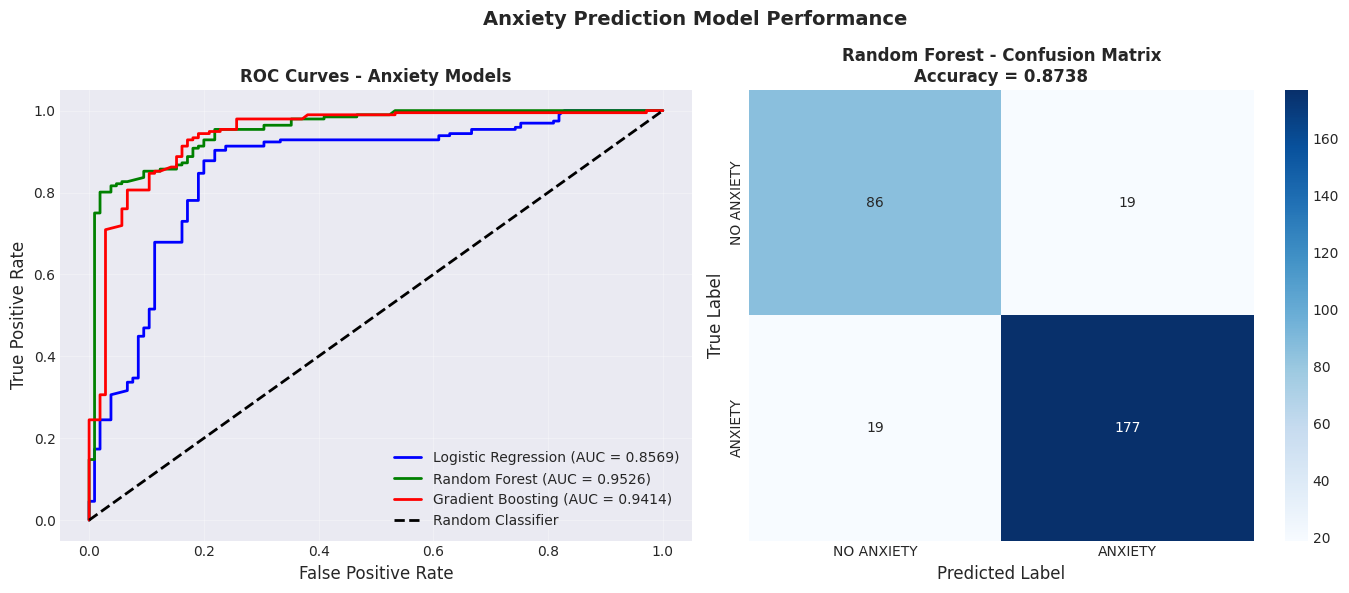

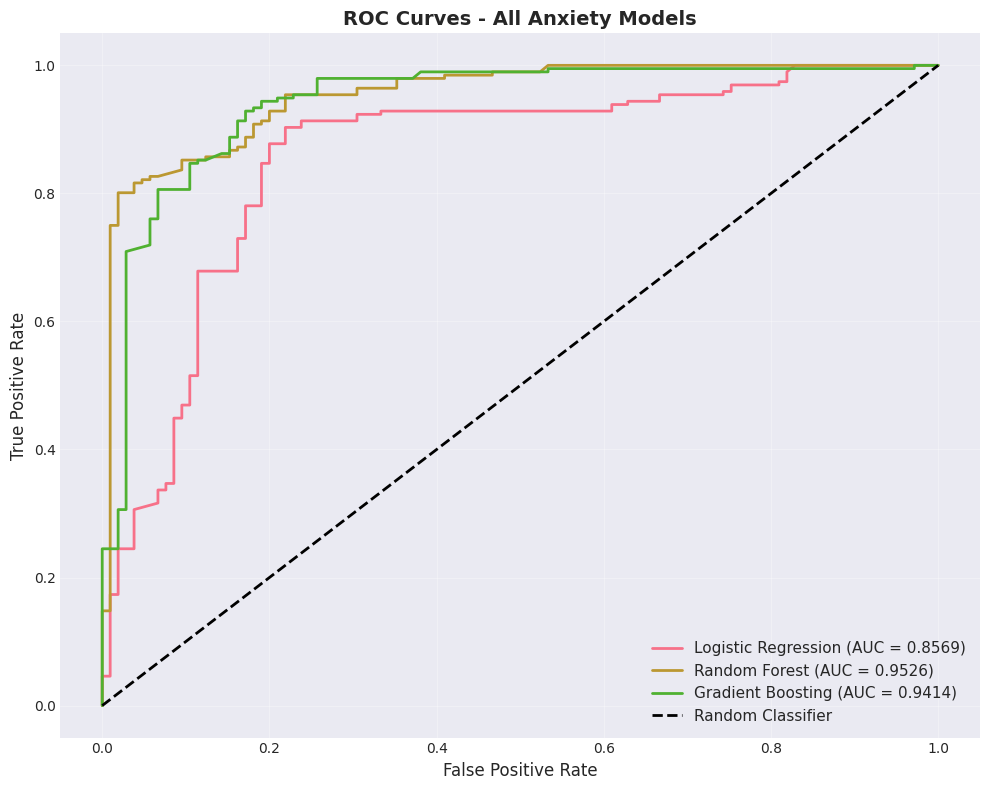

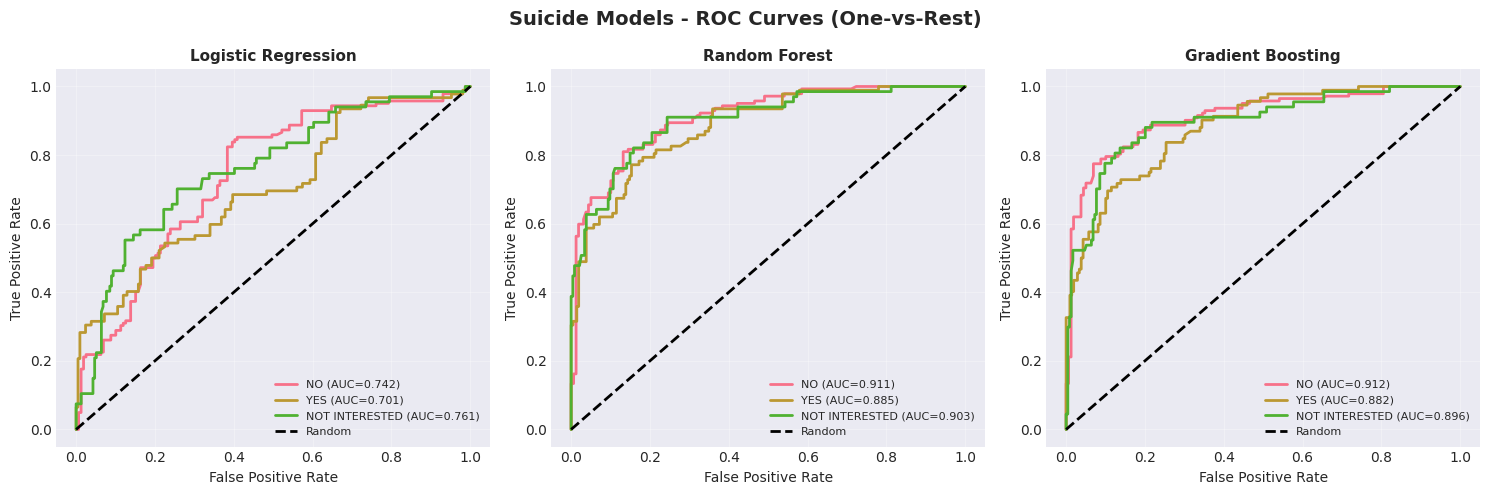

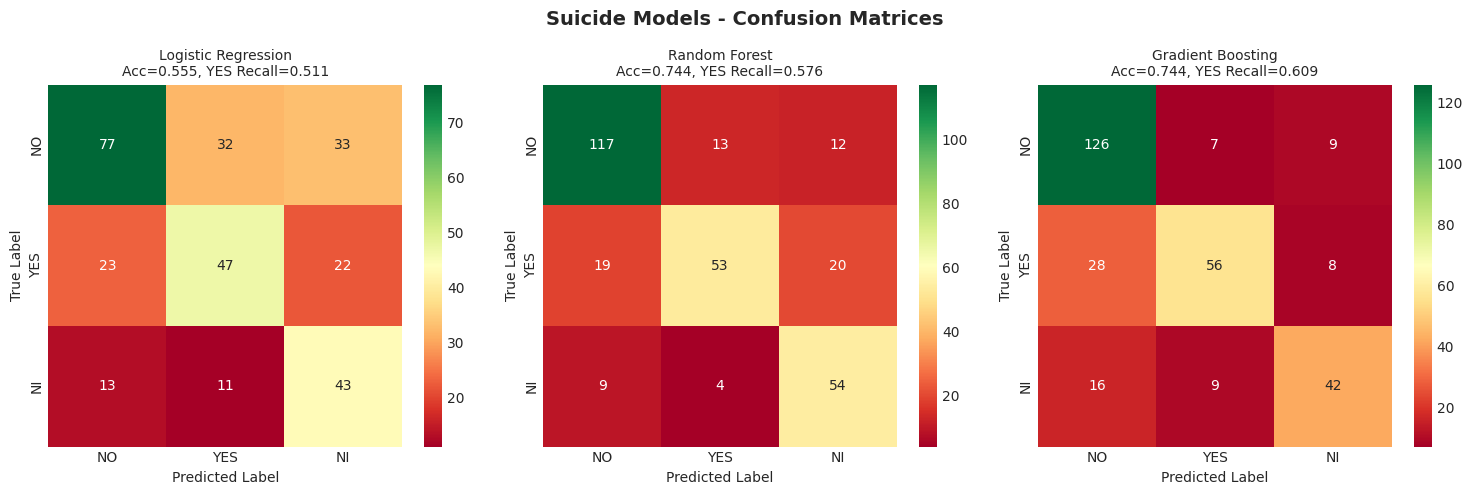

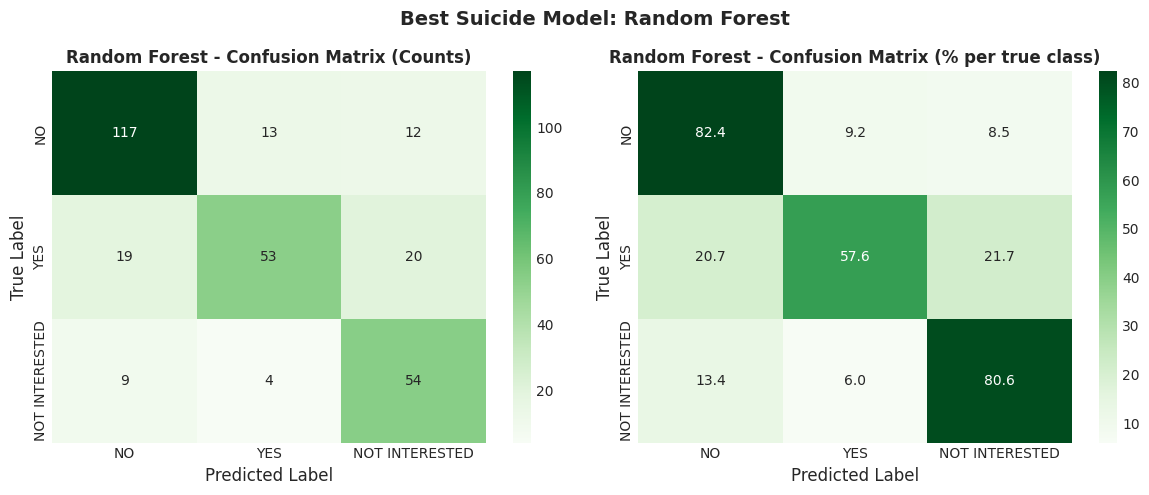

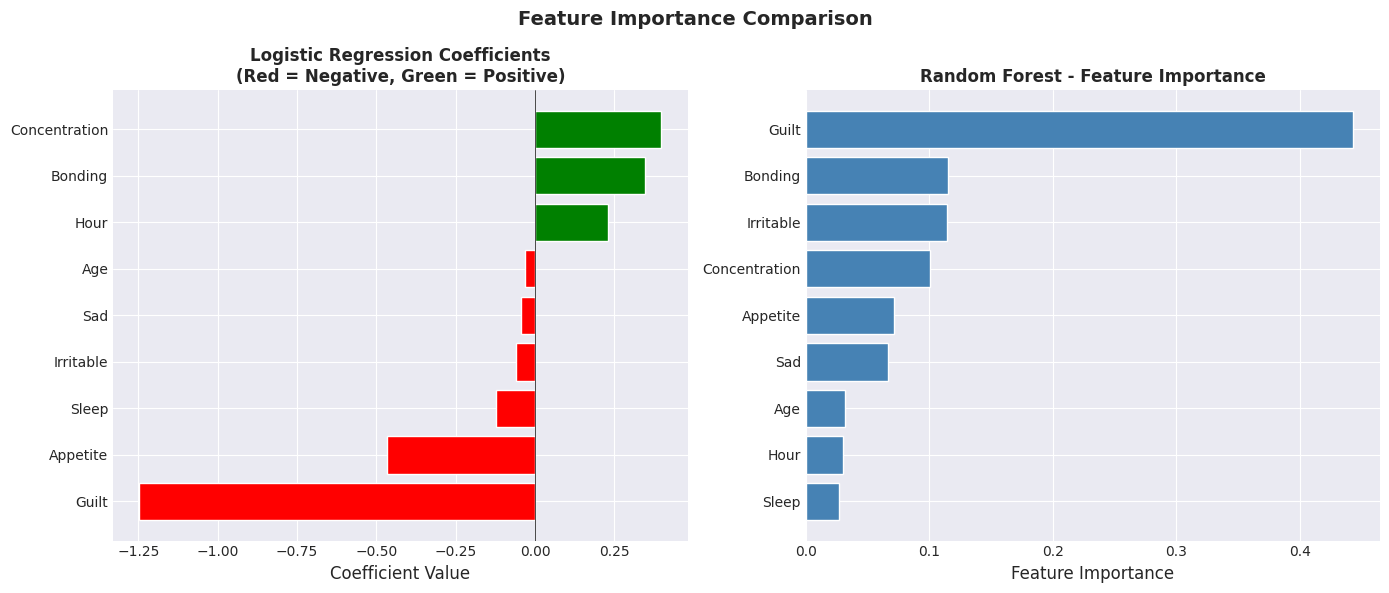

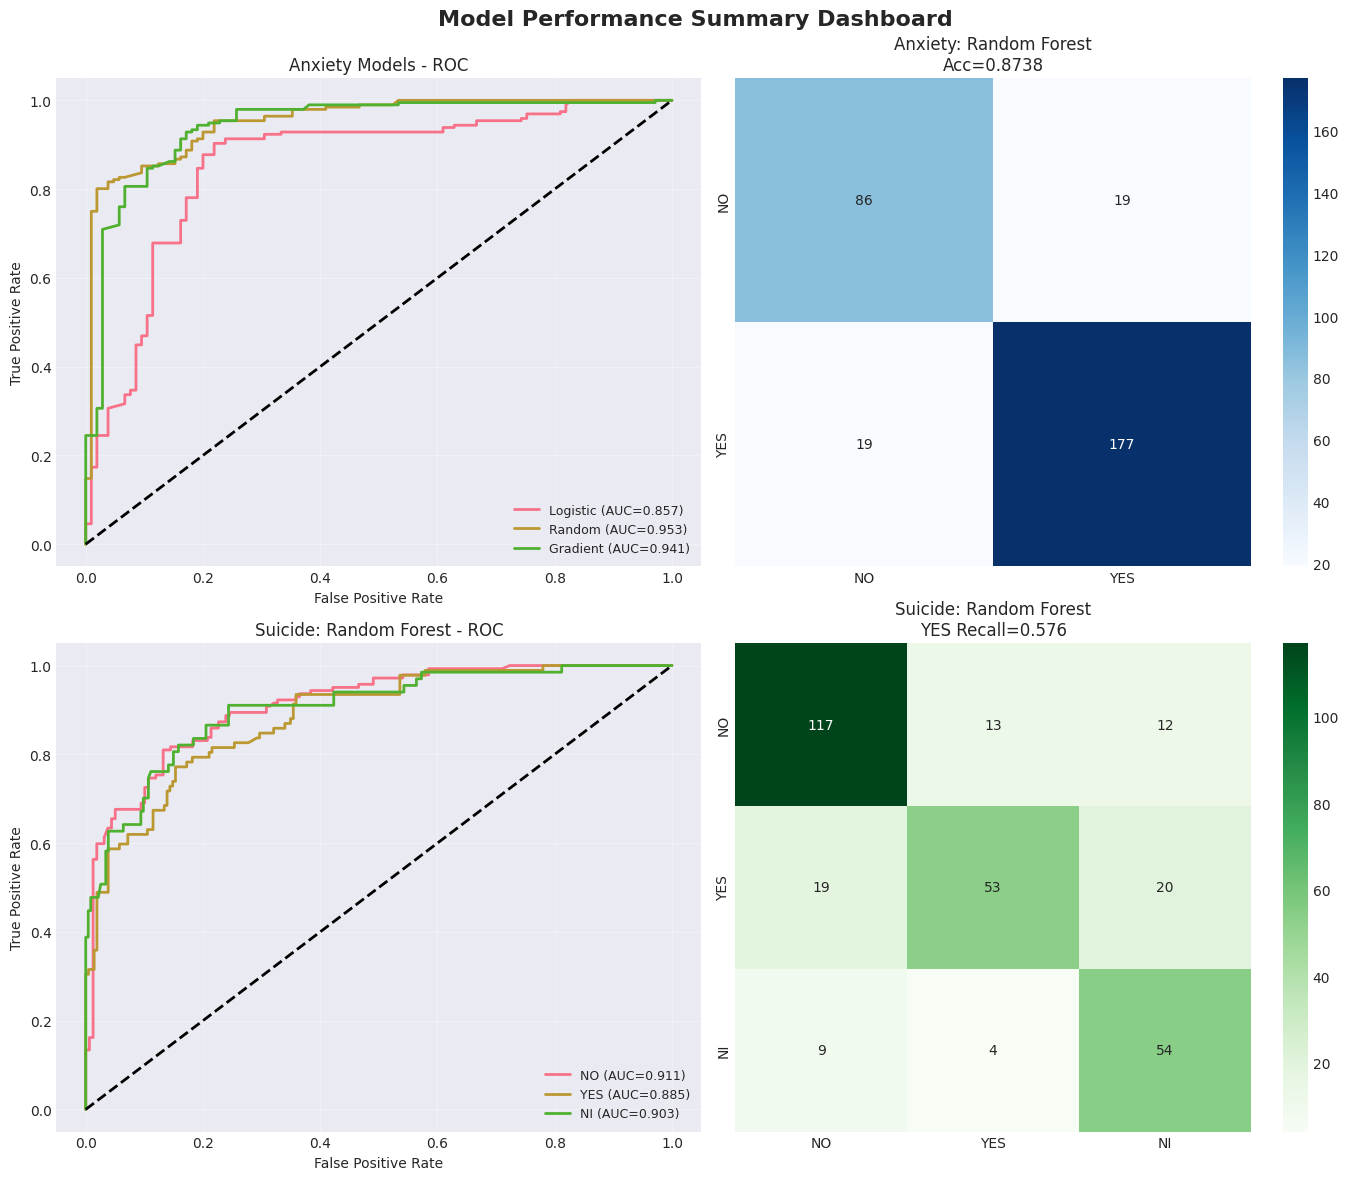

In [75]:

# ============================================================
#  VISUALIZATIONS 
# ============================================================

print("\n" + "="*70)
print("VISUALIZATIONS - DISPLAYING PLOTS")
print("="*70)

# ROC Curves + Confusion Matrix for Anxiety
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
colors = ['blue', 'green', 'red']
for i, (name, model) in enumerate(anxiety_models.items()):
    y_proba = model.predict_proba(X_test_a_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_a, y_proba)
    auc = roc_auc_score(y_test_a, y_proba)
    ax1.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - Anxiety Models', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

ax2 = axes[1]
y_test_pred_best = best_anxiety_model.predict(X_test_a_scaled)
cm = confusion_matrix(y_test_a, y_test_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['NO ANXIETY', 'ANXIETY'],
            yticklabels=['NO ANXIETY', 'ANXIETY'])
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_title(f'{best_anxiety_name} - Confusion Matrix\nAccuracy = {best_anxiety_results["Test Acc"]}', fontsize=12, fontweight='bold')

plt.suptitle('Anxiety Prediction Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)  # Small pause to allow rendering

# All Anxiety Models ROC (Detailed)
plt.figure(figsize=(10, 8))
for i, (name, model) in enumerate(anxiety_models.items()):
    y_proba = model.predict_proba(X_test_a_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_a, y_proba)
    auc = roc_auc_score(y_test_a, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Anxiety Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.pause(0.5)

# Suicide Models ROC Curves (One-vs-Rest)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, model) in enumerate(suicide_models.items()):
    ax = axes[idx]
    y_proba = model.predict_proba(X_test_s_scaled)
    
    for i, class_name in enumerate(['NO', 'YES', 'NOT INTERESTED']):
        fpr, tpr, _ = roc_curve(y_test_s == i, y_proba[:, i])
        auc = roc_auc_score(y_test_s == i, y_proba[:, i])
        ax.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Suicide Models - ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)

#  Suicide Models Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, model) in enumerate(suicide_models.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test_s_scaled)
    cm = confusion_matrix(y_test_s, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                xticklabels=['NO', 'YES', 'NI'],
                yticklabels=['NO', 'YES', 'NI'])
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    acc = accuracy_score(y_test_s, y_pred)
    recall_yes = recall_score(y_test_s, y_pred, average=None)[1]
    ax.set_title(f'{name}\nAcc={acc:.3f}, YES Recall={recall_yes:.3f}', fontsize=10)

plt.suptitle('Suicide Models - Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)

# Best Suicide Model - Detailed Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_test_pred_best_s = best_suicide_model.predict(X_test_s_scaled)
cm = confusion_matrix(y_test_s, y_test_pred_best_s)

ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax1,
            xticklabels=['NO', 'YES', 'NOT INTERESTED'],
            yticklabels=['NO', 'YES', 'NOT INTERESTED'])
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title(f'{best_suicide_name} - Confusion Matrix (Counts)', fontsize=12, fontweight='bold')

ax2 = axes[1]
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=ax2,
            xticklabels=['NO', 'YES', 'NOT INTERESTED'],
            yticklabels=['NO', 'YES', 'NOT INTERESTED'])
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_title(f'{best_suicide_name} - Confusion Matrix (% per true class)', fontsize=12, fontweight='bold')

plt.suptitle(f'Best Suicide Model: {best_suicide_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)

#  Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
coef_df = coefficients.copy()
coef_df_sorted = coef_df.sort_values('Coefficient', ascending=True)
colors_coef = ['red' if x < 0 else 'green' for x in coef_df_sorted['Coefficient']]
ax1.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors_coef)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Coefficient Value', fontsize=12)
ax1.set_title('Logistic Regression Coefficients\n(Red = Negative, Green = Positive)', fontsize=12, fontweight='bold')

ax2 = axes[1]
rf_model = anxiety_models['Random Forest']
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
ax2.barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)

# Performance Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Anxiety ROC
ax1 = axes[0, 0]
for i, (name, model) in enumerate(anxiety_models.items()):
    y_proba = model.predict_proba(X_test_a_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_a, y_proba)
    auc = roc_auc_score(y_test_a, y_proba)
    ax1.plot(fpr, tpr, lw=2, label=f'{name.split()[0]} (AUC={auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Anxiety Models - ROC')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# Anxiety Confusion
ax2 = axes[0, 1]
cm_best = confusion_matrix(y_test_a, best_anxiety_model.predict(X_test_a_scaled))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
ax2.set_title(f'Anxiety: {best_anxiety_name}\nAcc={best_anxiety_results["Test Acc"]}')

# Suicide ROC
ax3 = axes[1, 0]
y_proba_best_s = best_suicide_model.predict_proba(X_test_s_scaled)
for i, class_name in enumerate(['NO', 'YES', 'NI']):
    fpr, tpr, _ = roc_curve(y_test_s == i, y_proba_best_s[:, i])
    auc = roc_auc_score(y_test_s == i, y_proba_best_s[:, i])
    ax3.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=2)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title(f'Suicide: {best_suicide_name} - ROC')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(alpha=0.3)

# Suicide Confusion
ax4 = axes[1, 1]
cm_best_s = confusion_matrix(y_test_s, y_test_pred_best_s)
sns.heatmap(cm_best_s, annot=True, fmt='d', cmap='Greens', ax=ax4,
            xticklabels=['NO', 'YES', 'NI'],
            yticklabels=['NO', 'YES', 'NI'])
ax4.set_title(f'Suicide: {best_suicide_name}\nYES Recall={best_suicide_recall:.3f}')

plt.suptitle('Model Performance Summary Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.pause(0.5)


In [76]:

# ============================================================
#  CONFUSION MATRICES 
# ============================================================

print("\n" + "="*70)
print("CONFUSION MATRICES (Console Output)")
print("="*70)

y_test_pred_anxiety = best_anxiety_model.predict(X_test_a_scaled)
print(f"\nAnxiety Model ({best_anxiety_name}) - Confusion Matrix:")
print(confusion_matrix(y_test_a, y_test_pred_anxiety))
print("\nClassification Report:")
print(classification_report(y_test_a, y_test_pred_anxiety, target_names=['NO ANXIETY', 'ANXIETY (YES)']))

print(f"\nSuicide Model ({best_suicide_name}) - Confusion Matrix:")
print(confusion_matrix(y_test_s, y_test_pred_best_s))
print("\nClassification Report:")
print(classification_report(y_test_s, y_test_pred_best_s, target_names=['NO', 'YES', 'NOT INTERESTED']))



CONFUSION MATRICES (Console Output)

Anxiety Model (Random Forest) - Confusion Matrix:
[[ 86  19]
 [ 19 177]]

Classification Report:
               precision    recall  f1-score   support

   NO ANXIETY       0.82      0.82      0.82       105
ANXIETY (YES)       0.90      0.90      0.90       196

     accuracy                           0.87       301
    macro avg       0.86      0.86      0.86       301
 weighted avg       0.87      0.87      0.87       301


Suicide Model (Random Forest) - Confusion Matrix:
[[117  13  12]
 [ 19  53  20]
 [  9   4  54]]

Classification Report:
                precision    recall  f1-score   support

            NO       0.81      0.82      0.82       142
           YES       0.76      0.58      0.65        92
NOT INTERESTED       0.63      0.81      0.71        67

      accuracy                           0.74       301
     macro avg       0.73      0.74      0.73       301
  weighted avg       0.75      0.74      0.74       301



In [77]:
# ============================================================
# SAVE MODELS AND PREPROCESSORS FOR FLASK DEPLOYMENT
# ============================================================


# Create models directory if it doesn't exist
os.makedirs('./models', exist_ok=True)

print("\n" + "="*70)
print("SAVING MODELS AND PREPROCESSORS FOR DEPLOYMENT")
print("="*70)

# ============================================================
# SAVE THE BEST ANXIETY MODEL (Random Forest)
# ============================================================
best_anxiety_model = anxiety_models[best_anxiety_name]
joblib.dump(best_anxiety_model, './models/anxiety_model_best.pkl')
print(f" Saved: anxiety_model_best.pkl ({best_anxiety_name})")

# ============================================================
# SAVE THE BEST SUICIDE MODEL (Random Forest)
# ============================================================
best_suicide_model = suicide_models[best_suicide_name]
joblib.dump(best_suicide_model, './models/suicide_model.pkl')
print(f" Saved: suicide_model.pkl ({best_suicide_name})")

# ============================================================
# SAVE SCALERS
# ============================================================
joblib.dump(scaler_anxiety, './models/scaler_anxiety.pkl')
print(" Saved: scaler_anxiety.pkl")

joblib.dump(scaler_suicide, './models/scaler_suicide.pkl')
print(" Saved: scaler_suicide.pkl")

# ============================================================
# SAVE FEATURE COLUMNS
# ============================================================
joblib.dump(feature_cols, './models/feature_columns.pkl')
print(" Saved: feature_columns.pkl")

# ============================================================
#  SAVE LABEL MAPPINGS 
# ============================================================
label_mappings = {
    'anxiety': {0: 'NO ANXIETY', 1: 'ANXIETY (YES)'},
    'suicide': {0: 'NO', 1: 'YES', 2: 'NOT INTERESTED TO SAY'}
}
joblib.dump(label_mappings, './models/label_mappings.pkl')
print("✓ Saved: label_mappings.pkl")

# ============================================================
# SAVE RISK THRESHOLDS
# ============================================================
# Calculate risk thresholds based on anxiety probability distribution
anxiety_probs = best_anxiety_model.predict_proba(X_test_a_scaled)[:, 1]

risk_thresholds = {
    'low_risk': np.percentile(anxiety_probs, 25),
    'moderate_risk': np.percentile(anxiety_probs, 50),
    'high_risk': np.percentile(anxiety_probs, 75),
    'severe_risk': np.percentile(anxiety_probs, 90)
}
joblib.dump(risk_thresholds, './models/risk_thresholds.pkl')
print("✓ Saved: risk_thresholds.pkl")
print(f"   - Low risk threshold: {risk_thresholds['low_risk']:.3f}")
print(f"   - Moderate risk threshold: {risk_thresholds['moderate_risk']:.3f}")
print(f"   - High risk threshold: {risk_thresholds['high_risk']:.3f}")
print(f"   - Severe risk threshold: {risk_thresholds['severe_risk']:.3f}")

# ============================================================
# SAVE MODEL METADATA
# ============================================================
model_metadata = {
    'anxiety_model': {
        'type': 'Random Forest',
        'cv_auc': best_cv_auc,
        'test_accuracy': float(best_anxiety_results['Test Acc']),
        'test_auc': float([r['Test AUC'] for r in anxiety_results if r['Model'] == best_anxiety_name][0]),
        'brier_score': float([r['Brier'] for r in anxiety_results if r['Model'] == best_anxiety_name][0])
    },
    'suicide_model': {
        'type': 'Random Forest',
        'test_accuracy': float(best_suicide_results['Test Acc']),
        'yes_recall': float(best_suicide_results['Recall YES']),
        'yes_precision': float(best_suicide_results['Precision YES']),
        'yes_f1': float(best_suicide_results['F1 YES'])
    },
    'data_quality_note': 'Potential coding reversal detected in anxiety labels',
    'feature_columns': feature_cols
}
joblib.dump(model_metadata, './models/model_metadata.pkl')
print("✓ Saved: model_metadata.pkl")

# ============================================================
# VERIFY ALL FILES WERE SAVED
# ============================================================
print("\n" + "="*50)
print("VERIFYING SAVED FILES")
print("="*50)

saved_files = os.listdir('./models')
expected_files = [
    'anxiety_model_best.pkl',
    'suicide_model.pkl',
    'scaler_anxiety.pkl',
    'scaler_suicide.pkl',
    'feature_columns.pkl',
    'label_mappings.pkl',
    'risk_thresholds.pkl',
    'model_metadata.pkl'
]

for file in expected_files:
    if file in saved_files:
        file_size = os.path.getsize(f'./models/{file}') / 1024
        print(f"✓ {file} ({file_size:.1f} KB)")
    else:
        print(f"✗ {file} MISSING")

print("\n" + "="*50)
print("ALL MODELS AND PREPROCESSORS SAVED SUCCESSFULLY!")
print("="*50)
print("\nTo deploy the Flask app:")
print("1. Ensure app.py is in the same directory as the 'models' folder")
print("2. Run: python app.py")
print("3. Open browser at: http://localhost:5000")
print("="*50)



SAVING MODELS AND PREPROCESSORS FOR DEPLOYMENT
 Saved: anxiety_model_best.pkl (Random Forest)
 Saved: suicide_model.pkl (Random Forest)
 Saved: scaler_anxiety.pkl
 Saved: scaler_suicide.pkl
 Saved: feature_columns.pkl
✓ Saved: label_mappings.pkl
✓ Saved: risk_thresholds.pkl
   - Low risk threshold: 0.257
   - Moderate risk threshold: 0.691
   - High risk threshold: 0.836
   - Severe risk threshold: 0.886
✓ Saved: model_metadata.pkl

VERIFYING SAVED FILES
✓ anxiety_model_best.pkl (397.1 KB)
✓ suicide_model.pkl (456.5 KB)
✓ scaler_anxiety.pkl (1.1 KB)
✓ scaler_suicide.pkl (1.1 KB)
✓ feature_columns.pkl (0.1 KB)
✓ label_mappings.pkl (0.1 KB)
✓ risk_thresholds.pkl (0.2 KB)
✓ model_metadata.pkl (0.4 KB)

ALL MODELS AND PREPROCESSORS SAVED SUCCESSFULLY!

To deploy the Flask app:
1. Ensure app.py is in the same directory as the 'models' folder
2. Run: python app.py
3. Open browser at: http://localhost:5000


In [78]:

# ============================================================
#  FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

suicide_passing_models = [r for r in suicide_results if r['Sanity Pass']]

print(f"""
PROJECT COMPLETED SUCCESSFULLY
================================

EXACT TARGET LABELS:
  Anxiety: 0 = NO ANXIETY, 1 = ANXIETY (YES)
  Suicide: 0 = NO, 1 = YES, 2 = NOT INTERESTED TO SAY

DATA QUALITY FINDING:
  Potential coding reversal detected in anxiety labels
  'ANXIETY (YES)' patients: {anxiety_symptom_count:.2f} symptoms
  'NO ANXIETY' patients: {no_anxiety_symptom_count:.2f} symptoms

ANXIETY MODEL SELECTION:
  Selected Model: {best_anxiety_name}
  Selection Criterion: CV ROC-AUC ({best_cv_auc:.4f})
  Sanity Status: FAIL (all models fail due to data label issue)
  Note: Model predicts anxiety for asymptomatic patients - NOT clinically deployable

SUICIDE MODEL SELECTION (Two-Stage):
  Stage 1 (Gatekeeper): Models must PASS sanity test (healthy patient → NO)
  Stage 2 (Optimization): Select highest recall on YES class
  
  Models that PASSED sanity: {[r['Model'] for r in suicide_passing_models]}
  Models that FAILED sanity: {[r['Model'] for r in suicide_results if not r['Sanity Pass']]}
  
  Selected Model: {best_suicide_name}
  Recall on YES class: {best_suicide_recall:.3f} ({best_suicide_recall*100:.1f}%)
  F1 Score on YES class: {best_suicide_f1:.3f}
  Clinical limitation: {(1-best_suicide_recall)*100:.1f}% of high-risk patients would be missed

VISUALIZATIONS GENERATED:
  - 7 visualization windows displayed
  - ROC curves for all models
  - Confusion matrices with counts and percentages
  - Feature importance comparison
  - Performance summary dashboard

CRITICAL LIMITATIONS:
  1. Anxiety labels show potential reversal - anxiety model NOT clinically deployable
  2. Suicide model misses {(1-best_suicide_recall)*100:.1f}% of YES cases
  3. No external validation performed
  4. Asymptomatic patients absent from training data (n=0)
  5. Single dataset, no cross-site validation
""")

# Keep all plots open at the end
plt.show(block=True)


FINAL SUMMARY

PROJECT COMPLETED SUCCESSFULLY

EXACT TARGET LABELS:
  Anxiety: 0 = NO ANXIETY, 1 = ANXIETY (YES)
  Suicide: 0 = NO, 1 = YES, 2 = NOT INTERESTED TO SAY

DATA QUALITY FINDING:
  Potential coding reversal detected in anxiety labels
  'ANXIETY (YES)' patients: 3.31 symptoms
  'NO ANXIETY' patients: 3.64 symptoms

ANXIETY MODEL SELECTION:
  Selected Model: Random Forest
  Selection Criterion: CV ROC-AUC (0.9428)
  Sanity Status: FAIL (all models fail due to data label issue)
  Note: Model predicts anxiety for asymptomatic patients - NOT clinically deployable

SUICIDE MODEL SELECTION (Two-Stage):
  Stage 1 (Gatekeeper): Models must PASS sanity test (healthy patient → NO)
  Stage 2 (Optimization): Select highest recall on YES class

  Models that PASSED sanity: ['Logistic Regression', 'Random Forest']
  Models that FAILED sanity: ['Gradient Boosting']

  Selected Model: Random Forest
  Recall on YES class: 0.576 (57.6%)
  F1 Score on YES class: 0.654
  Clinical limitation: 42